# Эксперименты с прогнозированием

In [3]:
import pandas as pd

In [4]:
data = pd.read_csv('data.csv')

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11213 entries, 0 to 11212
Data columns (total 94 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       11213 non-null  object 
 1   Open                       11213 non-null  float64
 2   High                       11213 non-null  float64
 3   Low                        11213 non-null  float64
 4   Close                      11213 non-null  float64
 5   Volume                     11213 non-null  int64  
 6   Dividends                  11213 non-null  float64
 7   Stock Splits               11213 non-null  float64
 8   volume_adi                 11213 non-null  float64
 9   volume_obv                 11213 non-null  int64  
 10  volume_cmf                 11213 non-null  float64
 11  volume_fi                  11213 non-null  float64
 12  volume_em                  11213 non-null  float64
 13  volume_sma_em              11213 non-null  flo

## DNN

In [6]:
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [79]:
df = data.copy()
df['target'] = df['Close'].shift(-1)
df = df.dropna()
features = [c for c in df.columns if c not in ['Date','target']]

In [80]:
X = df[features].values.astype(np.float32)
y = df['target'].values.astype(np.float32).reshape(-1,1)

split_idx = int(len(X)*0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [81]:
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [82]:
class DNN(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

In [83]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DNN(X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [84]:
best_loss = np.inf
patience, trials = 10, 0
train_losses, val_losses = [], []

In [85]:
for epoch in range(100):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, train_loss={epoch_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        trials = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        trials += 1
        if trials >= patience:
            print("Early stopping")
            break

Epoch 1, train_loss=1.7211, val_loss=21974.1305
Epoch 2, train_loss=1.1552, val_loss=17020.5464
Epoch 3, train_loss=1.0230, val_loss=12959.5200
Epoch 4, train_loss=0.9014, val_loss=17896.2600
Epoch 5, train_loss=0.9860, val_loss=9567.6290
Epoch 6, train_loss=1.0736, val_loss=18698.3515
Epoch 7, train_loss=0.8965, val_loss=12470.1631
Epoch 8, train_loss=0.8525, val_loss=14535.6652
Epoch 9, train_loss=0.8152, val_loss=10096.7783
Epoch 10, train_loss=0.9388, val_loss=7863.4711
Epoch 11, train_loss=0.9684, val_loss=7376.6605
Epoch 12, train_loss=0.8263, val_loss=7337.7509
Epoch 13, train_loss=0.9777, val_loss=6440.2545
Epoch 14, train_loss=0.9752, val_loss=6497.8416
Epoch 15, train_loss=0.8697, val_loss=7542.1468
Epoch 16, train_loss=0.7668, val_loss=7304.7868
Epoch 17, train_loss=0.7710, val_loss=5108.1471
Epoch 18, train_loss=0.8127, val_loss=6888.3804
Epoch 19, train_loss=0.7777, val_loss=5335.2321
Epoch 20, train_loss=0.8816, val_loss=4667.6476
Epoch 21, train_loss=0.9709, val_loss=400

In [86]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
y_pred = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_pred.append(model(xb).cpu().numpy())
y_pred = np.vstack(y_pred).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"Test MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Test MSE=3259.1555, MAE=26.0093, R2=0.2708


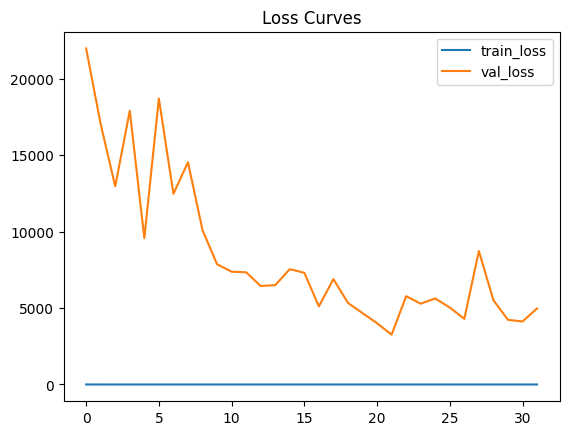

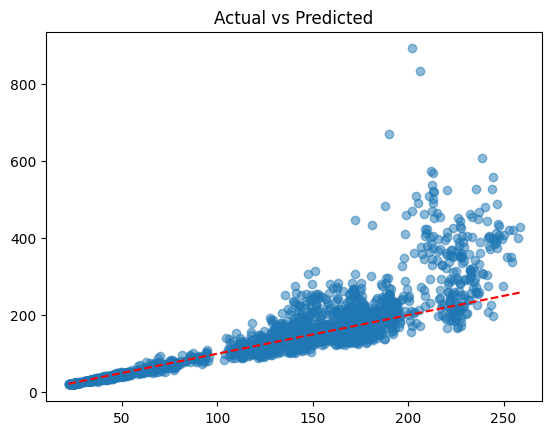

In [87]:
plt.figure()
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses,   label='val_loss')
plt.legend(); plt.title('Loss Curves'); plt.show()

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.title('Actual vs Predicted'); plt.show()

<ipython-input-88-d151c1c93598>:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  dates = pd.to_datetime(df.reset_index(drop=True)['Date']).iloc[split_idx:]


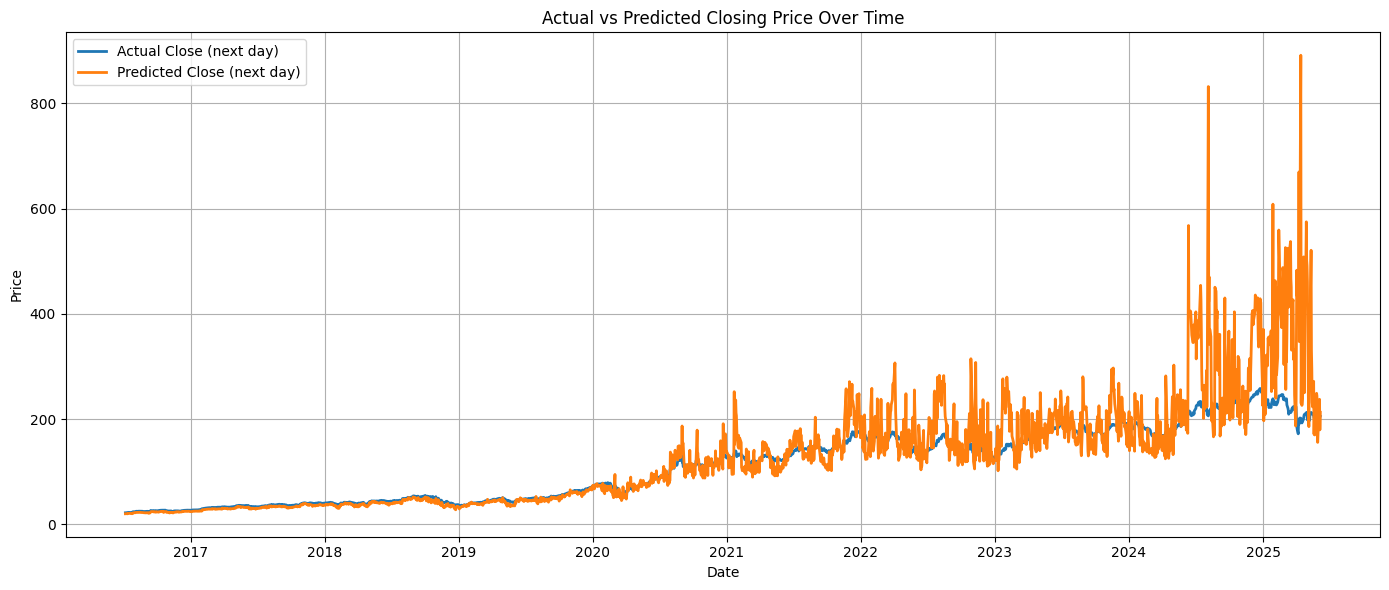

In [88]:
dates = pd.to_datetime(df.reset_index(drop=True)['Date']).iloc[split_idx:]

plt.figure(figsize=(14,6))
plt.plot(dates, y_test,  label='Actual Close (next day)', linewidth=2)
plt.plot(dates, y_pred,  label='Predicted Close (next day)', linewidth=2)
plt.title("Actual vs Predicted Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## TCN

In [102]:
SEQ_LEN    = 30
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [103]:
df = data.copy()
df['target'] = df['Close'].shift(-1)
df = df.dropna()
features = [c for c in df.columns if c not in ['Date','target']]

In [104]:
scaler = StandardScaler()
X = scaler.fit_transform(df[features].values.astype(float))
y = df['target'].values.astype(float)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split - SEQ_LEN:]
y_train, y_test = y[:split], y[split - SEQ_LEN:]

In [105]:
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = X
        self.y = y
        self.seq_len = seq_len
    def __len__(self):
        return len(self.X) - self.seq_len
    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]
        y_target = self.y[idx + self.seq_len]
        return (
            torch.from_numpy(x_seq).float(),
            torch.tensor(y_target).float()
        )

train_ds = SequenceDataset(X_train, y_train, SEQ_LEN)
test_ds  = SequenceDataset(X_test,  y_test,  SEQ_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [112]:
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride, dilation, padding, dropout):
        super().__init__()
        self.padding = padding
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.init_weights()

    def init_weights(self):
        for m in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(m.weight)

    def forward(self, x):
        # x: [B, C, L]
        out = self.conv1(x)
        if self.padding:
            out = out[:, :, :-self.padding]
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        if self.padding:
            out = out[:, :, :-self.padding]
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)

        return out + res



class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = num_inputs if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            padding = (kernel_size-1) * dilation
            layers.append(TemporalBlock(in_ch, out_ch,
                                        kernel_size, stride=1,
                                        dilation=dilation,
                                        padding=padding,
                                        dropout=dropout))
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        x = x.transpose(1,2)
        y = self.network(x)

        out = y[:, :, -1]
        return self.fc(out)

In [113]:
num_channels = [64, 64, 64]
model = TCN(num_inputs=len(features),
            num_channels=num_channels,
            kernel_size=3,
            dropout=0.2).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [114]:
train_losses, val_losses = [], []
best_val = float('inf')

for epoch in range(1, EPOCHS+1):
    model.train()
    total_train = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item() * xb.size(0)
    train_loss = total_train / len(train_loader.dataset)

    model.eval()
    total_val = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE).unsqueeze(1)
            total_val += criterion(model(xb), yb).item() * xb.size(0)
    val_loss = total_val / len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'tcn_best.pt')
    print(f"Epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

Epoch 01  train_loss=3.7518  val_loss=17051.6448
Epoch 02  train_loss=14.2248  val_loss=11854.2390
Epoch 03  train_loss=12.9488  val_loss=2268.2241
Epoch 04  train_loss=4.7040  val_loss=232.4542
Epoch 05  train_loss=3.7719  val_loss=551.0784
Epoch 06  train_loss=2.9574  val_loss=316.4135
Epoch 07  train_loss=2.5095  val_loss=5333.2713
Epoch 08  train_loss=2.1489  val_loss=5784.0555
Epoch 09  train_loss=2.5372  val_loss=4469.3171
Epoch 10  train_loss=2.7595  val_loss=6730.3153
Epoch 11  train_loss=2.0574  val_loss=1614.2528
Epoch 12  train_loss=2.0076  val_loss=3471.5318
Epoch 13  train_loss=2.3602  val_loss=339.1745
Epoch 14  train_loss=1.9801  val_loss=73.1892
Epoch 15  train_loss=1.8054  val_loss=307.2049
Epoch 16  train_loss=1.2587  val_loss=472.0055
Epoch 17  train_loss=1.3160  val_loss=481.0776
Epoch 18  train_loss=0.9823  val_loss=436.6695
Epoch 19  train_loss=1.0182  val_loss=543.2168
Epoch 20  train_loss=0.8394  val_loss=1596.4502
Epoch 21  train_loss=1.1271  val_loss=1028.1573

In [115]:
model.load_state_dict(torch.load('tcn_best.pt'))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        y_pred.append(model(xb).cpu().numpy().flatten())
        y_true.append(yb.numpy())
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)
print(f"\nTest MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Test MSE=48.4447, MAE=4.7309, R2=0.9892


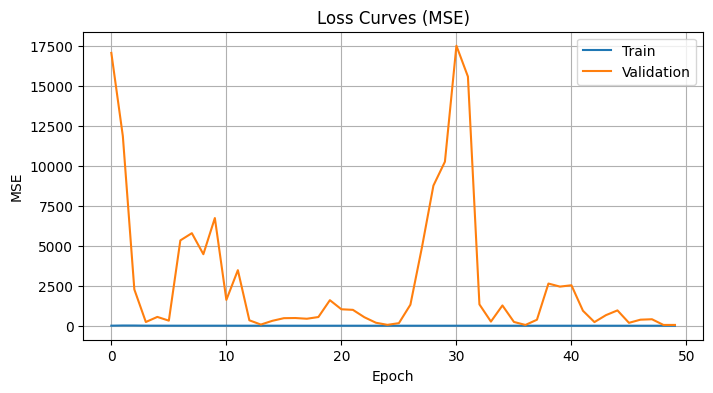

In [116]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.title("Loss Curves (MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(True)
plt.show()

<ipython-input-118-50095b0d320c>:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  dates = pd.to_datetime(df['Date']).iloc[split:].reset_index(drop=True)


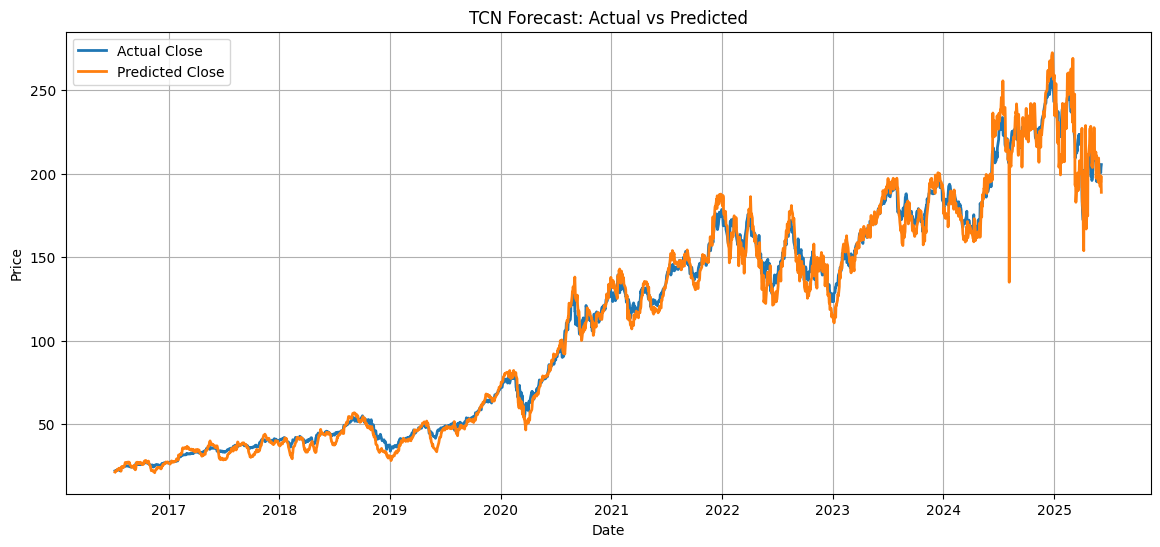

In [118]:
len_preds = len(y_pred)

dates = pd.to_datetime(df['Date']).iloc[split:].reset_index(drop=True)

dates = dates.iloc[:len_preds]

plt.figure(figsize=(14,6))
plt.plot(dates, y_true, label='Actual Close',   linewidth=2)
plt.plot(dates, y_pred, label='Predicted Close', linewidth=2)
plt.title("TCN Forecast: Actual vs Predicted")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.grid(True)
plt.show()